In [1]:
import pandas as pd
import numpy as np
from harmonicSearch import *


In [ ]:
import model_create as mc
from keras import optimizers

# model_ripple = mc.build_residual_mlp_ripple()
model_ripple = mc.build_random_forest()
model_mos_loss = mc.build_residual(input_dim=4, output_dim=2, model_name="mos_loss")
model_dio_loss = mc.build_residual(input_dim=4, output_dim=1, model_name="dio_loss")
model_leakage = mc.build_residual(input_dim=4, output_dim=1, model_name="leakage_current")
model_ESR_loss = mc.build_residual(input_dim=4, output_dim=4, model_name="ESR_loss")




# model_ripple.compile(
#     optimizer=optimizers.Adam(1e-3),
#     loss='mse',
#     metrics=['mae']
# )

model_leakage_current.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

model_loss.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

model_temp.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)


model_mode.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mode.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# model_ripple.summary()
# model_leakage_current.summary()
# model_loss.summary()
# model_temp.summary()
# model_mode.summary()

2026-04-14 22:59:48.529764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776175188.543145  339949 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776175188.547335  339949 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 22:59:48.561518: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776175190.026241  339949 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 56

In [3]:

df = pd.read_csv('/home/pcsl/Documents/plecs/sepic/plecs_python_auto/out/sepic_data/ripple_results.csv')
print(f"행 개수 :  {len(df)}")


행 개수 :  10020


In [4]:
from sklearn.preprocessing import LabelEncoder

# df_ccm = df[
#     df[["i_L1_Conduction_Mode", "i_L2_Conduction_Mode"]]
#     .eq("CCM")
#     .all(axis=1)
# ]
# print(f"행 개수 :  {len(df_ccm)}")

X = df[['L1', 'L2', 'C1', 'F']].values
y_ripple  = df[['i_L1_ripple_rate', 'V_out_ripple_rate']].values
# y_leakage = df[['leakage_avg']].values
y_loss = df[['mosfet_cond_loss', 'mosfet_switch_loss']].values
y_temp = df[['mosfet_temp']].values



In [5]:
y_L1_mode = df['i_L1_Conduction_Mode'].values
y_L2_mode = df['i_L2_Conduction_Mode'].values
le_L1 = LabelEncoder()
le_L2 = LabelEncoder()
y_L1_mode = le_L1.fit_transform(y_L1_mode)  # CCM→0, DCM→1
y_L2_mode = le_L2.fit_transform(y_L2_mode)
y_mode = np.column_stack((y_L1_mode, y_L2_mode))

splits = mc.split_data(X, y_ripple, y_loss, y_temp, y_mode)

X_train,       X_val,       X_test       = splits[0]
y_ripple_train,  y_ripple_val,  y_ripple_test  = splits[1]
y_loss_train,    y_loss_val,    y_loss_test    = splits[2]
y_temp_train,    y_temp_val,    y_temp_test    = splits[3]
y_mode_train,    y_mode_val,    y_mode_test    = splits[4]

## Scaler

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# HS용
y_ripple_mmscaler  = MinMaxScaler()
y_leakage_mmscaler = MinMaxScaler()

y_ripple_mmscaler.fit_transform(y_ripple)
# y_leakage_mmscaler.fit_transform(y_leakage)



# 학습용
X_train, X_val, X_test, x_scaler = mc.scale_data(
    X_train, X_val, X_test,
    scaler=MinMaxScaler()
)

y_ripple_train, y_ripple_val, y_ripple_test, y_ripple_scaler = mc.scale_data(
    y_ripple_train, y_ripple_val, y_ripple_test,
    scaler=StandardScaler()
)

# y_leakage_train, y_leakage_val, y_leakage_test, y_leakage_scaler = mc.scale_data(
#     y_leakage_train, y_leakage_val, y_leakage_test,
#     scaler=StandardScaler()
# )

y_loss_train, y_loss_val, y_loss_test, y_loss_scaler = mc.scale_data(
    y_loss_train, y_loss_val, y_loss_test,
    scaler=StandardScaler()
)

y_temp_train, y_temp_val, y_temp_test, y_temp_scaler = mc.scale_data(
    y_temp_train, y_temp_val, y_temp_test,
    scaler=StandardScaler()
)



  Ripple Model
Metric               Train        Val       Test
--------------------------------------------------
mse                 0.0118     0.0175     0.0416
mae                 0.0184     0.0259     0.0379
r2                  0.9882     0.9830     0.9562


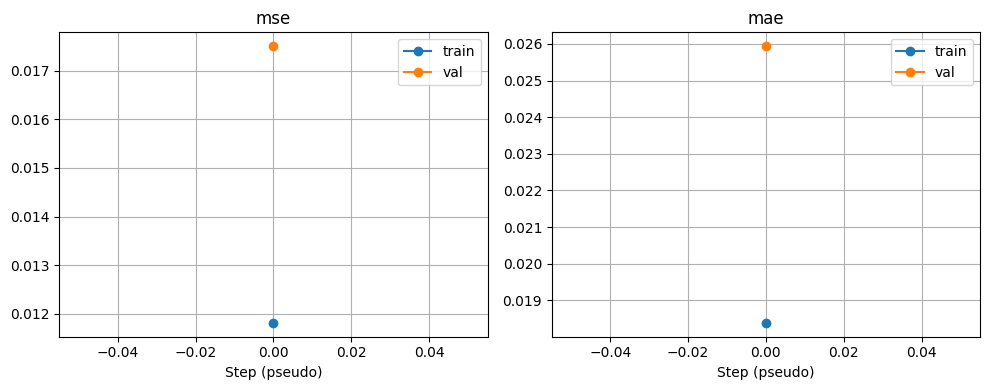

In [7]:

history_ripple = mc.train_and_evaluate_sklearn(
    model_ripple,
    X_train, y_ripple_train,
    X_val,   y_ripple_val,
    X_test,  y_ripple_test,
    model_name='Ripple Model',
)


I0000 00:00:1776175192.722923  340340 service.cc:148] XLA service 0x7f26180168a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776175192.722955  340340 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2026-04-14 22:59:52.777878: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776175192.963614  340340 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1776175193.854393  340340 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



  Loss Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.0289     0.0306     0.0295
compile_metrics     0.0988     0.0996     0.1039


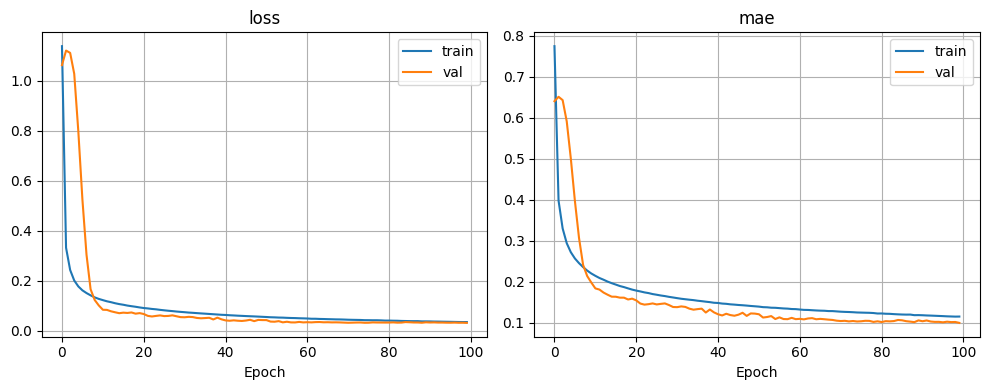


  Temp Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.0900     0.0968     0.0940
compile_metrics     0.1540     0.1573     0.1626


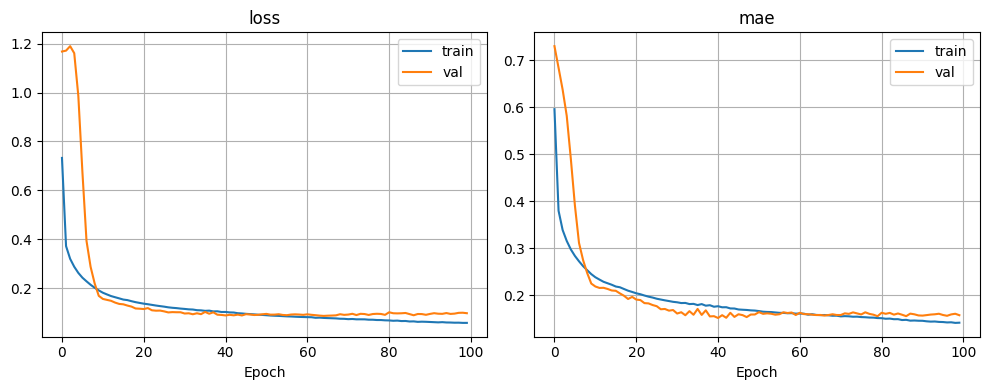

In [8]:
# history_ripple = mc.train_and_evaluate(
#     model_ripple,
#     X_train, y_ripple_train,
#     X_val,   y_ripple_val,
#     X_test,  y_ripple_test,
#     model_name='Ripple Model',
#     epochs=100, batch_size=100
# )

# history_leakage = mc.train_and_evaluate(
#     model_leakage_current,
#     X_train, y_leakage_train,
#     X_val,   y_leakage_val,
#     X_test,  y_leakage_test,
#     model_name='Leakage Model',
#     epochs=100, batch_size=100
# )

history_loss = mc.train_and_evaluate(
    model_loss,
    X_train, y_loss_train,
    X_val,   y_loss_val,
    X_test,  y_loss_test,
    model_name='Loss Model',
    epochs=100, batch_size=100
)

history_temp = mc.train_and_evaluate(
    model_temp,
    X_train, y_temp_train,
    X_val,   y_temp_val,
    X_test,  y_temp_test,
    model_name='Temp Model',
    epochs=100, batch_size=100
)


# history_L_mode = mc.train_and_evaluate(
#     model_mode,
#     X_train, y_mode_train,  # shape (N,2)
#     X_val, y_mode_val,
#     X_test, y_mode_test,
#     model_name='L Mode Model',
#     epochs=1000,
#     batch_size=100
# )

y_mode_train shape: (7013, 2)

  L Mode Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.0112     0.0107     0.0043
compile_metrics     0.7858     0.7977     0.7979


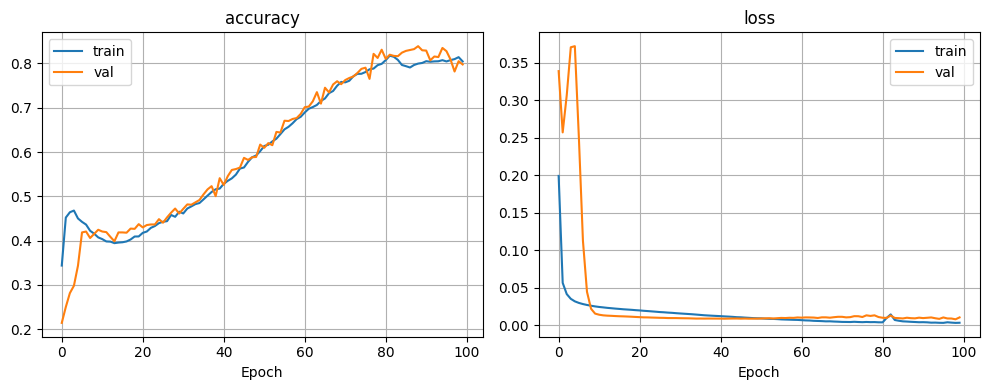

In [9]:
print("y_mode_train shape:", y_mode_train.shape)


history_L_mode = mc.train_and_evaluate(
    model_mode,
    X_train, y_mode_train,
    X_val,   y_mode_val,
    X_test,  y_mode_test,
    model_name='L Mode Model',
    epochs=100, batch_size=100
)


# hs

In [10]:
from harmonicSearch import *

In [11]:
model_dict ={}
model_dict["ripple"] = model_ripple
model_dict["loss"] = model_loss
model_dict["temp"] = model_temp


scaler_dict = {}

scaler_dict["std_x"] = x_scaler
scaler_dict["std_ripple"] = y_ripple_scaler
scaler_dict["std_loss"] = y_loss_scaler
scaler_dict["std_temp"] = y_temp_scaler
scaler_dict["mm_ripple"] = y_ripple_mmscaler

hs_result = harmony_search(model= model_dict,
                           scaler = scaler_dict ,
                           max_iters = 2000,
                           hmcr = 0.7,
                           )

Initialize HM ...
[1 / 2000] best_f = 5.552, best_m={'lripple': np.float64(0.09148137237231078), 'vripple': np.float64(0.0037518045850339077), 'cond_loss': np.float32(4.358717), 'sw_loss': np.float32(1.1688699), 'temp': np.float32(7.886638)}
[2 / 2000] best_f = 5.552, best_m={'lripple': np.float64(0.09148137237231078), 'vripple': np.float64(0.0037518045850339077), 'cond_loss': np.float32(4.358717), 'sw_loss': np.float32(1.1688699), 'temp': np.float32(7.886638)}
[3 / 2000] best_f = 5.552, best_m={'lripple': np.float64(0.09148137237231078), 'vripple': np.float64(0.0037518045850339077), 'cond_loss': np.float32(4.358717), 'sw_loss': np.float32(1.1688699), 'temp': np.float32(7.886638)}
[4 / 2000] best_f = 5.552, best_m={'lripple': np.float64(0.09148137237231078), 'vripple': np.float64(0.0037518045850339077), 'cond_loss': np.float32(4.358717), 'sw_loss': np.float32(1.1688699), 'temp': np.float32(7.886638)}
[5 / 2000] best_f = 5.552, best_m={'lripple': np.float64(0.09148137237231078), 'vrippl

# Ga

In [12]:
# import numpy as np

# def fitness_func(ga_instance, solution, solution_idx):

#     x_dict = {
#         "L1": solution[0],
#         "L2": solution[1],
#         "C": solution[2],
#         "fsw": solution[3],
#     }

#     # 🔹 모델 예측
#     metrics = evaluate_lt(model = model_dict,
#                           scaler = scaler_dict, 
#                           x = x_dict)

#     lr = metrics["lripple"]
#     vr = metrics["vripple"]
#     cond_loss = metrics["cond_loss"]
#     sw_loss = metrics["sw_loss"]
#     temp = metrics["temp"]


#     penalty_term = (
#         1e7 * (min(0, lr)**2) +
#         1e7 * (min(0, vr)**2)
#         )

#     lr = max(0.0, lr)
#     vr = max(0.0, vr)

#     ripple = np.array([[lr, vr]])
#     ripple_norm = y_ripple_mmscaler.transform(ripple)

#     i = ripple_norm[0, 0]
#     v = ripple_norm[0, 1]

#     p = 6
#     cost = cond_loss + sw_loss + temp + (v**p + i**p )**(1/p)

#     # penalty 포함
#     cost = cost + penalty_term

#     return -cost   # GA는 maximize라서 음수

In [13]:
# !pip install pygad

In [14]:
# import pygad
# ga_instance = pygad.GA(
#     num_generations = 100, # 세대 진화 횟수(iter)
#     num_parents_mating = 3, # 한 세대에서 n개의 조합을 부모로 선택
#     sol_per_pop = 20, # 한 세대 조합 후보 개수
#     num_genes = 4, # 입력 변수 개수

#     fitness_func = fitness_func,

#     gene_space = [
#         {'low': 1e-4, 'high': 1e-3},        # L1
#         {'low': 1e-5, 'high': 4.6e-4},     # L2
#         {'low': 1e-5, 'high': 4.6e-4},     # C
#         {'low': 5e4, 'high': 10.5e4},       # fsw
#     ],
#     mutation_type = "random",
#     mutation_num_genes = 2,
#     mutation_probability = 0.3,
# )

# ga_instance.run()

# solution, solution_fitness, _ = ga_instance.best_solution()

In [15]:
print(f"HS_result : {hs_result}")


# print("\n\nGA_result:")
# print("L1 =", solution[0])
# print("L2   =", solution[1])
# print("C   =", solution[2])
# print("fsw   =", solution[3])
# print("Predicted Cost =", -solution_fitness)

HS_result : ({'fsw': 60000.0, 'L1': 0.0009768401886114239, 'L2': 6.296813093181922e-05, 'C': 0.00046}, {'lripple': np.float64(0.08094831605336668), 'vripple': np.float64(0.0037073652815532362), 'cond_loss': np.float32(4.330354), 'sw_loss': np.float32(0.9669141), 'temp': np.float32(7.6762533)}, np.float64(5.316090030700163), [np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110703899), np.float64(5.552327110

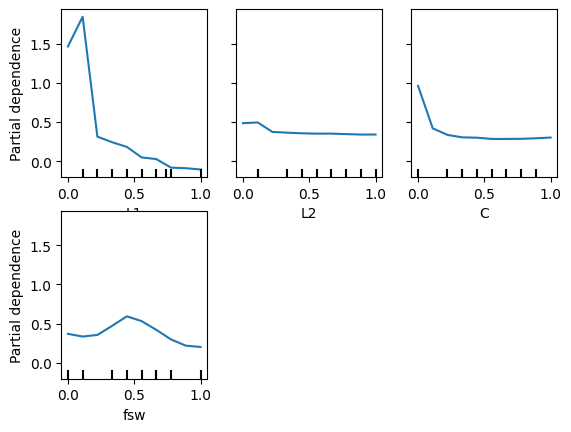

In [17]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = [0, 1, 2, 3]  # L1, L2, C, fsw

PartialDependenceDisplay.from_estimator(
    model_ripple,
    X_train,
    features=features,
    feature_names=["L1", "L2", "C", "fsw"]
)

plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# fsw sweep
F_values = np.linspace(60e3, 105e3, 200)

# 고정값
L1 = 0.0009915872795781893
L2 = 2.112814560102331e-05
C = 0.0004571868421441684

# 입력 행렬 생성 (200 x 3)
X_sweep = np.column_stack((
    np.full_like(F_values, L1),
    np.full_like(F_values, L2),
    np.full_like(F_values, C),
    F_values
))

# scaling
X_scaled = x_scaler.transform(X_sweep)

# ripple 예측 (한 번에!)
y_ripple_scaled = model_ripple.predict(X_scaled, verbose=0)

# inverse scaling
y_ripple_pred = y_ripple_scaler.inverse_transform(y_ripple_scaled)

# 분리
i_ripple_list = y_ripple_pred[:,0]
v_ripple_list = y_ripple_pred[:,1]

plt.figure()
plt.plot(F_values, i_ripple_list)
plt.grid(True)
plt.show()


TypeError: ForestRegressor.predict() got an unexpected keyword argument 'verbose'

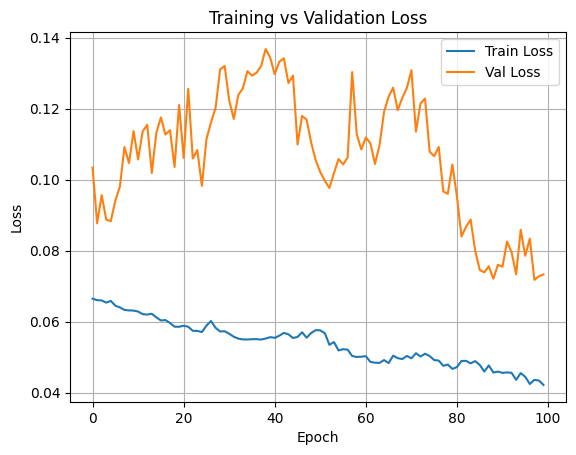

In [ ]:
plt.figure()
plt.plot(history_ripple.history['loss'], label='Train Loss')
plt.plot(history_ripple.history['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

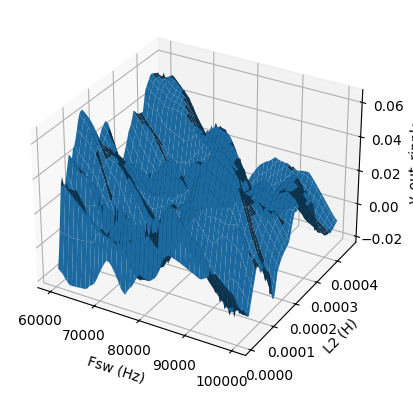

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# sweep 범위 설정
F_values = np.linspace(60e3, 100e3, 80)
L2_values = np.linspace(1e-5, 46e-5, 80)

# 2D grid 생성
F_grid, L2_grid = np.meshgrid(F_values, L2_values)

L1 = 0.0001
C  = 0.00046

# 전체 조합 → 80*80 = 6400개
X_sweep = np.column_stack((
    np.full(F_grid.size, L1),
    L2_grid.ravel(),
    np.full(F_grid.size, C),
    F_grid.ravel()
))

# scaling
X_scaled = x_scaler.transform(X_sweep)

# 예측
y_ripple_scaled = model_ripple.predict(X_scaled, verbose=0)

# inverse scaling
y_ripple_pred = y_ripple_scaler.inverse_transform(y_ripple_scaled)

# ripple 값 reshape
i_ripple = y_ripple_pred[:,1].reshape(F_grid.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(F_grid, L2_grid, i_ripple)

ax.set_xlabel("Fsw (Hz)")
ax.set_ylabel("L2 (H)")
ax.set_zlabel("v_out_ripple")

plt.show()